In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel('ResumeScannerDataset_with_Names.xlsx')
df

Applicant Name      Category  \
0      Kenneth Scott  Data Science   
1        Larry Lewis  Data Science   
2        Daniel Hill  Data Science   
3       Joshua Davis  Data Science   
4     Justin Sanchez  Data Science   
..               ...           ...   
957   Larry Gonzalez       Testing   
958      James Perez       Testing   
959  Abigail Johnson       Testing   
960  Donald Robinson       Testing   
961    Kevin Johnson       Testing   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [ ]:
# Check for duplicate
df.duplicated().sum()

np.int64(0)

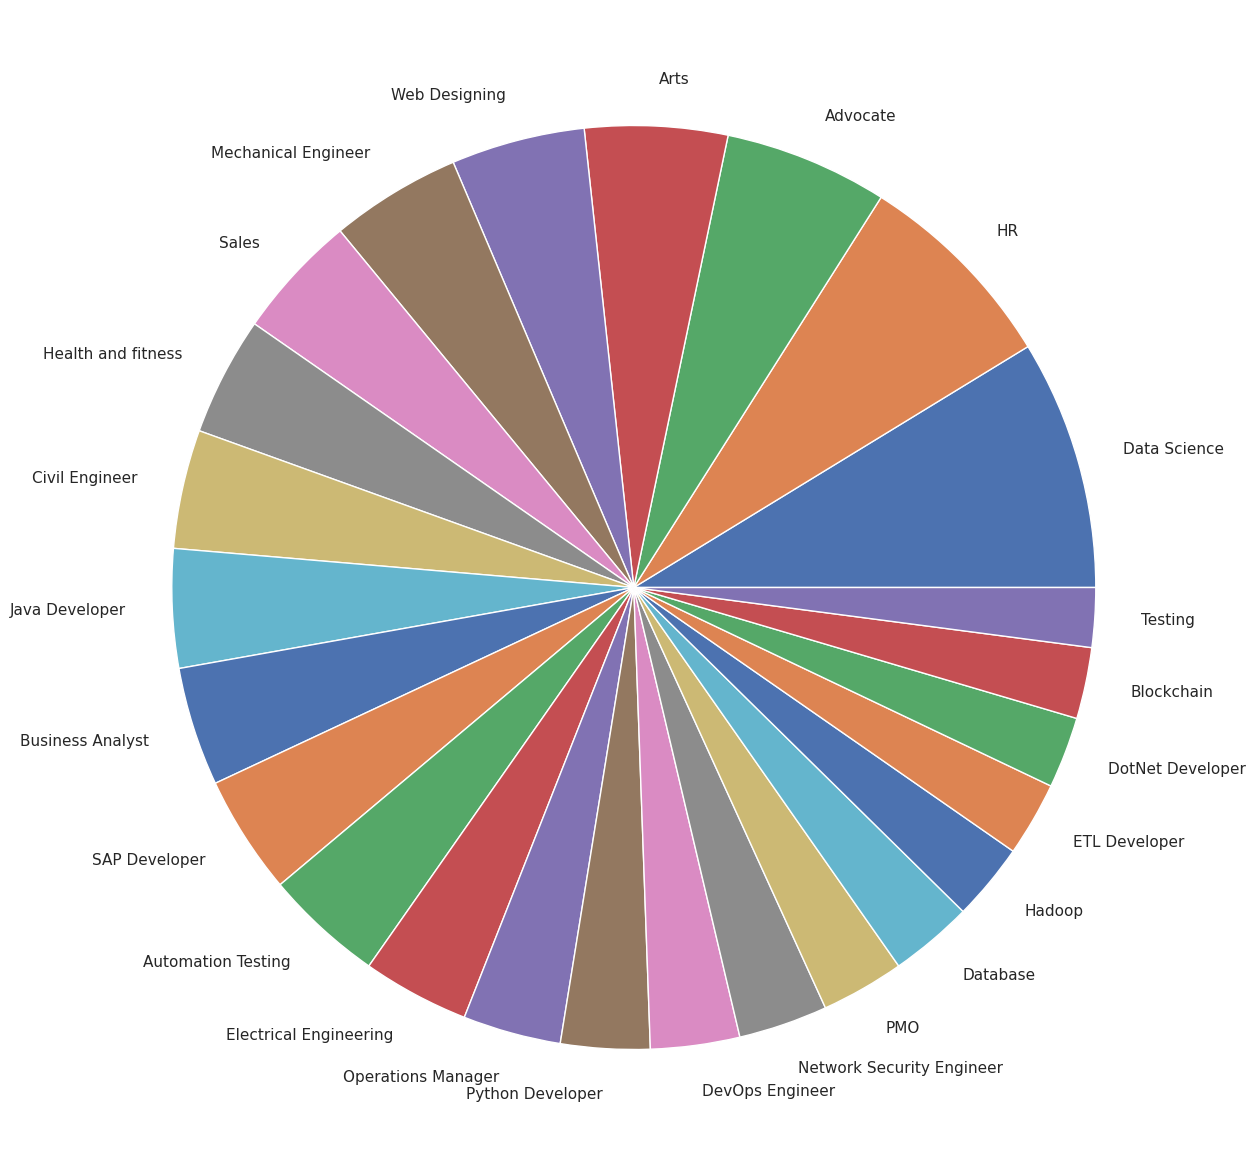

In [ ]:
# Data visualization Using pie chart

counts = df['Category'].value_counts()
labels = df['Category'].unique()
plt.figure(figsize=(25,15))
plt.pie(counts,labels=labels)
plt.show()

In [ ]:
# Display full resume text to inspect and prepare for data cleaning
pd.set_option('display.max_colwidth', None)
df['Resume']

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details _x000D_\n_x000D_\nData Science Assurance Associate _x000D_\n_x000D_\nData Science Assurance Associate - Ernst & Young LLP_x000D_\nSkill Details _x000D_\nJAVASCRIPT- Exprience - 24 months_x000D_\njQuery- Exprience - 24 months_x000D_\nPython- Exprience - 24 monthsCompany Details _x000D_\ncompany - Ernst & Young LLP_x000D_\ndescription - Fraud Investigations and Dispute Services   Assurance_x000D_\nTECHNOLOGY ASSISTED REVIEW_x000D_\nTAR (Technology Assisted Review) assists in accelerating the review process and run analytics and generate rep

In [ ]:
# Data Cleaning
# Import regular expressions module for text cleaning
import re

def cleanResume(txt):
    cleanText = re.sub(r'http\S+\s*', ' ', str(txt)) # Convert input to string and remove URLs (http/https links)
    cleanText = re.sub(r'RT|cc', ' ', cleanText)
    cleanText = re.sub(r'#\S+', '', cleanText)
    cleanText = re.sub(r'@\S+', ' ', cleanText)
    cleanText = re.sub(r'[^\w\s]', ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)
    cleanText = re.sub(r'\s+', ' ', cleanText)
    return cleanText


In [ ]:
# Displays the updated cleaned Resume column
df['Resume'] = df['Resume'].apply(lambda x: cleanResume(x))
df['Resume']

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   Skills Programming Languages Python pandas numpy scipy scikit learn matplotlib Sql Java JavaScript JQuery Machine learning Regression SVM Na ve Bayes KNN Random Forest Decision Trees Boosting techniques Cluster Analysis Word Embedding Sentiment Analysis Natural Language processing Dimensionality reduction Topic Modelling LDA NMF PCA Neural Nets Database Visualizations Mysql SqlServer Cassandra Hbase ElasticSearch D3 js DC js Plotly kibana matplotlib ggplot Tableau Others Regular Expression HTML CSS Angular 6 Logstash Kafka Python Flask Git Docker computer vision Open CV and understanding of Deep learning Education Details _x000D_ _x000D_ Data Science Assurance Associate _x000D_ _x000D_ Data Science Assurance Associate Ernst Young LLP_x000D_ Skill Details _x000D_ JAVASCRIPT Exprience 24 months_x000D_ jQuery Exprience 24 months_x000D_ Python Exprience 24 monthsCompany Details _x000D_ company Ernst Young LLP_x000D_ description Fraud Investigations and Dispute Services Assurance_x000D_ TECHNOLOGY ASSISTED REVIEW_x000D_ TAR Technology Assisted Review assists in a elerating the review process and run analytics and generate reports _x000D_ Core member of a team helped in developing automated review platform tool from scratch for assisting E discovery domain this tool implements predictive coding and topic modelling by automating reviews resulting in reduced labor costs and time spent during the lawyers review _x000D_ Understand the end

In [ ]:
# Words to categorical value
from sklearn.preprocessing import LabelEncoder                       #LabelEncoder gives order to categories
le = LabelEncoder()                                                  # Create an instance of LabelEncoder
le.fit(df['Category'])                                               # Learn all unique category labels from the 'Category' column
df['Category'] = le.transform(df['Category'])
df.Category.unique()



array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

In [ ]:
# Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer                     #converts text data into numbers
tfidf = TfidfVectorizer(stop_words='english')                                   #removes common words like:"the", "is", "and", "in"
tfidf.fit(df['Resume'])
requiredText = tfidf.transform(df['Resume'])



In [ ]:
# Import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (70% train, 30% test)
x_train, x_test, y_train, y_test = train_test_split(requiredText, df['Category'], test_size=0.2, random_state=45)
x_train.shape

(769, 8112)

In [ ]:
#Trining using K Neighbours
from sklearn.neighbors import KNeighborsClassifier

# Create model
clf = KNeighborsClassifier()

# Train model
clf.fit(x_train, y_train)

# Predict
y_pred = clf.predict(x_test)

print(y_pred)

[ 2 13  0  3 16 19  4  9 22  4 16 23  9  3  5 13  3  3  5  1 22  1 15 15
 15  8  7 15 13  2 16  7 18  2 15  1  1  8 19 23 18 20  6 16  2 16 15 12
  3  2 15 18  7 24 22 16 16 11 22 15  7 16  3 13 15 15 24  8 15  1 24  9
 12 11 23 12 10 12 21 17 15 15 20 19 15 10 23 12 21 13 20 10 12  3  2 23
 17 23  8 15  8 23 24 16 12 21 12 22 11 15  8 14 20 10  8  9  4  8 24  2
  7 14  4 14 18 20 18 23 14 23 18  1 19  8 10  6  6 18  2 15  3 10  7  8
 12 24 10  8  3  6 12  8  0  7 13  6 18 22  1  6  9  3 16 24 11 11 19 19
 18 24 24  3  6 18 24 15 11 19 23 13 23  0 22 22 12  8 20  1 10 15  8  8
 11]


In [205]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# 1. We increase n_neighbors to 15-20.
# Default is 5 (too precise). Higher K = smoother/less accurate boundaries.
clf = OneVsRestClassifier(KNeighborsClassifier(n_neighbors=18))

# 2. Train on your 70% split
clf.fit(x_train, y_train)

# 3. Predict
y_pred = clf.predict(x_test)

# 4. Check results
print(f"Targeted Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Calculate additional metrics for multiclass classification
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Targeted Accuracy: 90.67%
Precision: 0.94
Recall: 0.91
F1-Score: 0.91

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      0.38      0.55         8
           2       0.80      1.00      0.89         8
           3       1.00      1.00      1.00        11
           4       1.00      0.75      0.86         4
           5       1.00      1.00      1.00         2
           6       1.00      0.78      0.88         9
           7       1.00      1.00      1.00         7
           8       1.00      0.94      0.97        16
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         7
          12       1.00      0.90      0.95        10
          13       1.00      1.00      1.00         7
          14       0.67      0.50      0.57         4
          15       0.95      1.00      0.

In [206]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Define your Job Description

job_description =   """

Job Description
Core Responsibilities:

Analyzing the Testing Requirements

Preparing Test Plans, Test Scenarios

Preparing Test Cases

Executing the test cases

Tracking bugs

Coordinating developers in order to fix it

Preparing test summary reports

Reporting quality manager

Attending meeting

Projects & Experience:

Project Name: 1.Web Based Time Attendance Application

Environment: Windows-7, Vista, Windows XP, Windows 8, Windows 10

Clients: MCCIA, Sapphire Park, Bramha Suncity, Wanless hospital

Role: Software Testing

Project Name Android: 1.Time Attendance Application 2.Vehicle Tracking System 3.Vistor Management System

Environment: Android Mobile, Android Tablet

Clients: Vankan Security

Role: Application Testing

Project Name: 1.Web Based Factory Automation Process 2.Web Based Annual Maintenance Charges

Project Name: Web Based Library Management System

Skill Summary & Duration:

TESTING - Exprience - 24 months

WINDOWS XP - Exprience - 24 months

CSS - Exprience - 6 months

DATABASE - Exprience - 6 months

DATABASE TESTING - Exprience - 6 months

"""

# 2. Vectorization with N-grams (captures phrases like "Machine Learning")
# Using (1, 2) ensures it looks for both single words and two-word pairs

tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df['Resume'])
jd_vector = tfidf.transform([job_description])


# 3. Calculate Similarity and Map to Row Index

scores = cosine_similarity(jd_vector, tfidf_matrix).flatten()

# 4. Create a clean results table (FIXED: removed the newline after pd.DataFrame)

match_results = pd.DataFrame({
    'Row_Number': df.index,
    'Category': df['Category'],
    'Name': df['Applicant Name'], # Use 'Applicant Name' as per the dataset
    'Match_Percentage': (scores * 100).round(2)
})

# Sort resumes by highest match percentage and select top 100 matches
top_100_matches = match_results.sort_values(by='Match_Percentage', ascending=False).head(100)

# 5. Display Leaderboard
print(f"{'Rank':<5} | {'Row Index':<10} | {'Category':<20} | {'Name':<25} | {'Match %'}")
print("-" * 85)
for i, (idx, row) in enumerate(top_100_matches.iterrows(), 1):
    print(f"{i:<5} | {int(row['Row_Number']):<10} | {row['Category']:<20} | {row['Name']:<25} | {row['Match_Percentage']}%")

Rank  | Row Index  | Category             | Name                      | Match %
-------------------------------------------------------------------------------------
1     | 926        | 23                   | Emily Torres              | 65.28%
2     | 912        | 23                   | Timothy Torres            | 65.28%
3     | 905        | 23                   | Nicholas Thomas           | 65.28%
4     | 919        | 23                   | Brian Harris              | 65.28%
5     | 954        | 23                   | Emily Hernandez           | 65.28%
6     | 898        | 23                   | Jacob Wright              | 65.28%
7     | 947        | 23                   | Anthony Lopez             | 65.28%
8     | 940        | 23                   | Isabella Jones            | 65.28%
9     | 933        | 23                   | Brandon Taylor            | 65.28%
10    | 961        | 23                   | Kevin Johnson             | 65.28%
11    | 479        | 2                    | 

/tmp/ipykernel_12736/2068223619.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Match_Percentage', y='Name', data=top_20_matches_sorted, palette=top_20_matches_sorted['Color'].tolist(), legend=False)


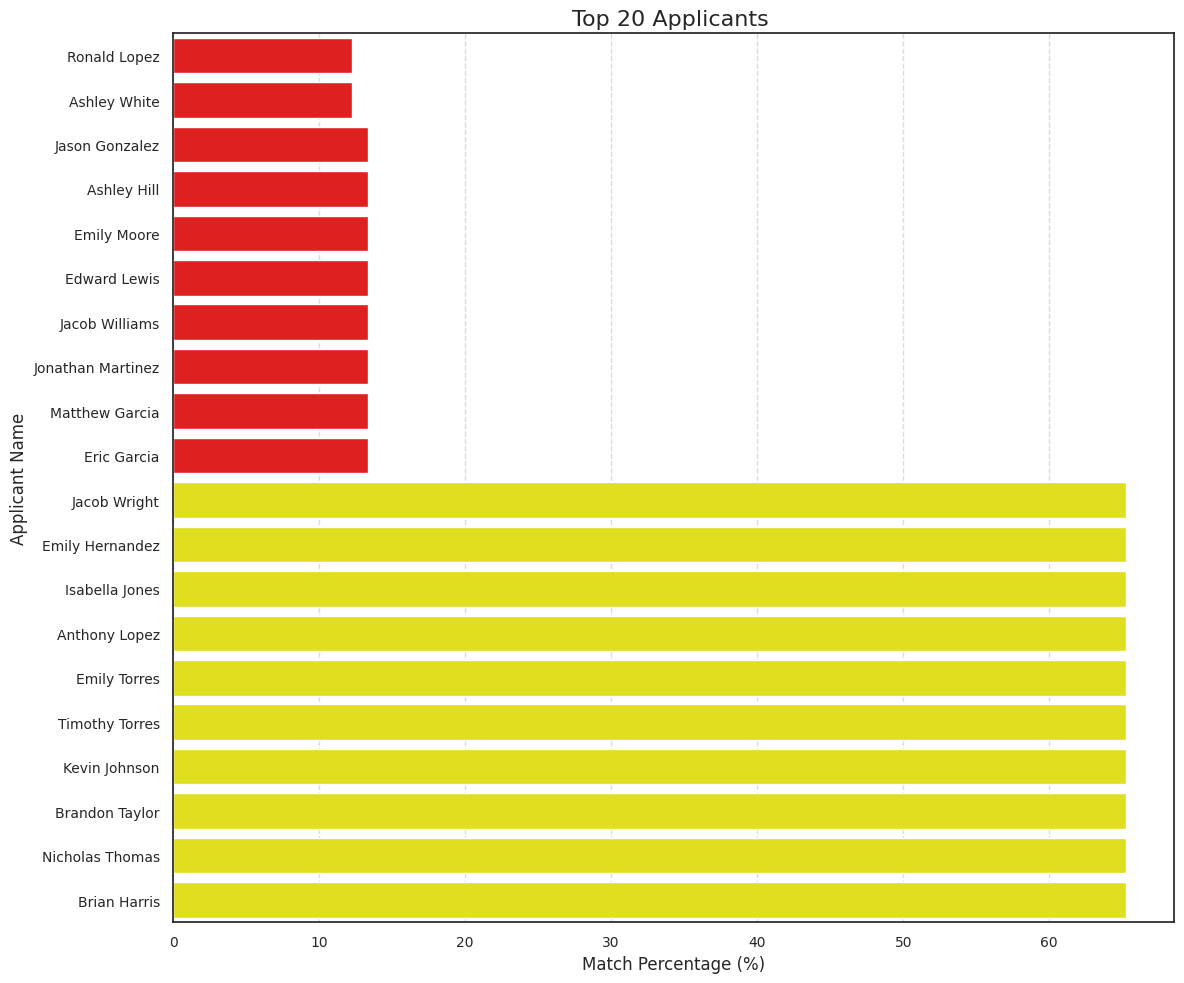

In [ ]:
# Sort the top_20_matches DataFrame by 'Match_Percentage' in ascending order for better visualization
top_20_matches_sorted = top_20_matches.sort_values(by='Match_Percentage', ascending=True)

# Define colors based on Match_Percentage
conditions =
 [
    top_20_matches_sorted['Match_Percentage'] > 80,
    (top_20_matches_sorted['Match_Percentage'] >= 50) & (top_20_matches_sorted['Match_Percentage'] <= 80),
    top_20_matches_sorted['Match_Percentage'] < 50
  ]

choices = ['green', 'yellow', 'red']
top_20_matches_sorted['Color'] = np.select(conditions, choices, default='blue') # Default can be any color

plt.figure(figsize=(12, 10))
sns.barplot(x='Match_Percentage', y='Name', data=top_20_matches_sorted, palette=top_20_matches_sorted['Color'].tolist(), legend=False)
plt.title('Top 20 Applicants ', fontsize=16)
plt.xlabel('Match Percentage (%)', fontsize=12)
plt.ylabel('Applicant Name', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()